In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [7]:
GAMBIT_RANDOM = "../data/gambit-output/gambit-random-v5-lh-21984853/FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "../data/gambit-output/gambit-diver-v5-relicd-21984874/FS_MSSM7atQ_diver_gambit.hdf5"
MODELGEN = "../data/modelgen-output/modelgen-v5/SP_MSSM7atQ_random_modelgen.hdf5"

In [33]:
scan_gambit_random = h5py.File(GAMBIT_RANDOM, 'r')["MSSM"]
scan_gambit_diver = h5py.File(GAMBIT_DIVER, 'r')["MSSM"]
scan_modelgen = h5py.File(MODELGEN, 'r')["MSSM"]

mask = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:] == 1
lnL_oh2_gr = scan_gambit_diver["#lnL_oh2 @DarkBit::lnL_oh2_upperlimit"][mask]
oh2_gr = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas"][mask]

mask = (scan_modelgen["MO_Omega"][:] != -1) & (scan_modelgen["MO_Omega"][:] < 1)
oh2_mg = scan_modelgen["MO_Omega"][mask]



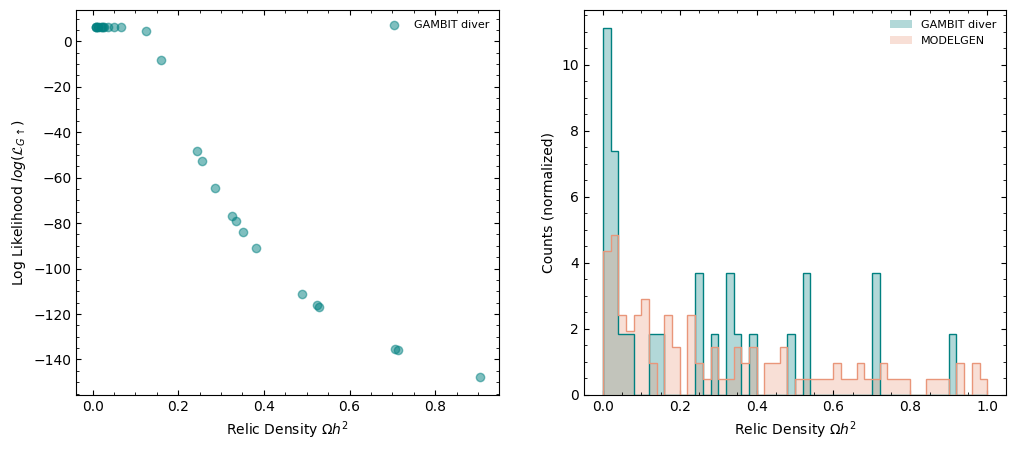

In [36]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.scatter(oh2_gr, lnL_oh2_gr, alpha=0.5, color='teal', label="GAMBIT diver")
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax1.legend(frameon=False, fontsize=8)
ax1.set_xlabel("Relic Density $\\Omega h^2$")
ax1.set_ylabel("Log Likelihood $log(\\mathcal{L}_{G \\uparrow})$")

ax2.hist(oh2_gr, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax2.hist(oh2_gr, bins=50, range=(0,1), density=True, histtype='step', color='teal')
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, histtype='step', color='darksalmon')
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.set_xlabel("Relic Density $\\Omega h^2$")
ax2.set_ylabel("Counts (normalized)")
ax2.legend(frameon=False, fontsize=8)

plt.show()